# Pure-space spectral diagnostic: smooth=0.3, nugget-free vs nugget=0

This notebook fits each hourly pure-space slice with isotropic Hybrid Vecchia under two variants:

- `nugget_free`: estimate `sigmasq`, `range`, and `nugget`
- `nugget0`: estimate `sigmasq` and `range`, with nugget fixed at zero

Both use `smooth=0.3`, `mean_design='latlon'`, and the same every-k resolution thinning used in the previous pure-space resolution checks.

The spectral diagnostic compares the detrended empirical residual spectrum against the theoretical fitted Matern spectrum. For `nugget_free`, the theoretical spectrum includes a flat nugget floor before scaling to the empirical spectrum. Because the thinning is every-k over the ordered grid, the empirical spectrum is a masked/zero-filled periodogram and should be read as a shape diagnostic rather than an exact Whittle likelihood.


In [1]:
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_space_iso_050826 import (
    HybridSpaceIsoTrendVecchiaFit,
    HybridSpaceIsoNoNuggetTrendVecchiaFit,
)

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 200)
print('SRC:', SRC)
print('device:', DEVICE)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

SMOOTH = 0.3
RESOLUTION_STRIDES = [8, 4, 2, 1]
MEAN_DESIGN = 'latlon'

HYBRID_SPEC = {
    'limit_A': 10,
    'target_chunk_size': 512,
}

VARIANTS = {
    'nugget_free': {
        'class': HybridSpaceIsoTrendVecchiaFit,
        'model': 'HybridSpaceIso_A10_exactloc',
        'kernel': 'hybrid_space_iso_tonly_exactloc',
        'p_labels': ['sigmasq', 'range', 'nugget'],
        'init': {'sigmasq': 13.0, 'range': 0.25, 'nugget': 2.5},
    },
    'nugget0': {
        'class': HybridSpaceIsoNoNuggetTrendVecchiaFit,
        'model': 'HybridSpaceIsoNoNugget_A10_exactloc',
        'kernel': 'hybrid_space_iso_nugget0_tonly_exactloc',
        'p_labels': ['sigmasq', 'range'],
        'init': {'sigmasq': 13.0, 'range': 0.25},
    },
}

LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FULL = True
RUN_SPECTRUM = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_pure_space_spectral_s03_nugget_compare_hybrid_050826'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('smooth:', SMOOTH)
print('variants:', list(VARIANTS))


day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
smooth: 0.3
variants: ['nugget_free', 'nugget0']


In [3]:
def phys_to_log(init, p_labels):
    return [np.log(init[p]) for p in p_labels]


def backmap(raw, p_labels, variant):
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if 'nugget' not in est:
        est['nugget'] = 0.0
    return est


def make_full_params(variant):
    spec = VARIANTS[variant]
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(spec['init'], spec['p_labels'])]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


In [4]:
loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

print('monthly_mean:', round(monthly_mean, 4))
print('day keys:', day_keys[0], '...', day_keys[-1])
print('full grid:', grid_coords_full.shape)
print('unique lat/lon:', len(np.unique(np.round(grid_coords_full[:,0], 6))), len(np.unique(np.round(grid_coords_full[:,1], 6))))


--- Global Monthly Mean for 2024-7: 257.9726 ---
monthly_mean: 257.9726
day keys: 2024_07_y24m07day03_hm00:53 ... 2024_07_y24m07day03_hm07:48
full grid: (18126, 2)
unique lat/lon: 114 159


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def thin_hour_map(hour_map, stride):
    n_full = grid_coords_full.shape[0]
    thin_idx = np.arange(0, n_full, int(stride), dtype=np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def make_hybrid_ordering(grid_coords):
    coords = np.ascontiguousarray(grid_coords.astype(np.float64))
    hybrid_order = orderings.maxmin_cpp(coords).astype(np.int64)
    ordered_coords = np.ascontiguousarray(coords[hybrid_order])
    nns_map = orderings.find_nns_l2(ordered_coords, max_nn=HYBRID_SPEC['limit_A'])
    return hybrid_order, ordered_coords, nns_map


def build_model(variant, input_map, nns_map):
    spec = VARIANTS[variant]
    return spec['class'](
        smooth=SMOOTH,
        input_map=input_map,
        nns_map=nns_map,
        limit_A=HYBRID_SPEC['limit_A'],
        target_chunk_size=HYBRID_SPEC['target_chunk_size'],
        mean_design=MEAN_DESIGN,
    )


def make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    spec = VARIANTS[variant]
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'variant': variant,
        'smooth': float(SMOOTH),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'full',
        'model': spec['model'],
        'kernel': spec['kernel'],
        'coord_mode': 'regular-grid every-k thinning, then max-min hybrid ordering; covariance on Source_Latitude/Source_Longitude',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range']),
        'est_nugget': float(est.get('nugget', 0.0)),
        **diag,
        'total_conditioning_nominal': HYBRID_SPEC['limit_A'],
        'limit_A': HYBRID_SPEC['limit_A'],
    }
    return row


In [6]:
def fit_full_variant(variant, hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map_regular, thin_grid_regular, _ = thin_hour_map(hour_map, stride)
    hybrid_order, thin_grid, nns_map = make_hybrid_ordering(thin_grid_regular)
    thin_map = {k: v[hybrid_order].contiguous() for k, v in thin_map_regular.items()}
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(f'{variant} | smooth={SMOOTH} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(variant, thin_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params(variant)
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    p_labels = VARIANTS[variant]['p_labels']
    est = backmap(out[:len(p_labels)], p_labels, variant)
    row = make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['variant','resolution_label','loss','est_sigmasq','est_range','est_nugget','total_s']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


In [7]:
fit_rows = []
if RUN_FULL:
    for variant in VARIANTS:
        for hour_idx in HOUR_IDX_LIST:
            for stride in RESOLUTION_STRIDES:
                fit_rows.append(fit_full_variant(variant, hour_idx, stride))
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

fit_df = pd.DataFrame(fit_rows)
full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
round_df(fit_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved full fits:', full_path)
display(round_df(fit_df))

param_rows = []
for _, row in fit_df.iterrows():
    for p in ['sigmasq', 'range', 'nugget']:
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'variant': row['variant'],
            'smooth': row['smooth'],
            'parameter': p,
            'estimate': row[f'est_{p}'],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)



nugget_free | smooth=0.3 | hour=1 | 2024_07_y24m07day03_hm00:53 | x8 | n_grid=2,266 | n_valid=2,259
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=2259, m mean/med/max=9.9/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.564846 / Max Grad: 6.42e-06 ---
Converged: max_grad 6.42e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 9.780446476161298, 'range': 0.6218150741725289, 'nugget': 3.193355720176075}
RESULT: {'resolution_label': 'x8', 'variant': 'nugget_free', 'loss': 1.5648, 'total_s': 0.264, 'est_sigmasq': 9.7804, 'est_range': 0.6218, 'est_nugget': 3.1934}

nugget_free | smooth=0.3 | hour=1 | 2024_07_y24m07day03_hm00:53 | x4 | n_grid=4,532 | n_valid=4,518
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=4518, m mean/med/max=10.0/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.491650 / Max Grad: 4.37e-06 ---
Converged: max_grad 4.37e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 10.941449092840458, '

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,variant,smooth,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,limit_A
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,latlon,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.5648,0,1,0.0201,0.2439,0.2640,2266,2259,0.9969,9.7804,0.6218,3.1934,1,2259,10.0,10,2259,10,10
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,nugget_free,0.3,latlon,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.4916,0,1,0.0233,0.6732,0.6965,4532,4518,0.9969,10.9414,0.5132,2.0446,1,4518,10.0,10,4518,10,10
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,nugget_free,0.3,latlon,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.5355,0,1,0.0410,1.0828,1.1238,9063,9033,0.9967,11.7375,0.2871,2.3254,1,9033,10.0,10,9033,10,10
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,nugget_free,0.3,latlon,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.4229,0,1,0.1741,1.8596,2.0337,18126,18067,0.9967,11.9809,0.2888,1.5708,1,18067,10.0,10,18067,10,10
4,20240703,2,1,2024_07_y24m07day03_hm01:53,8,x8,nugget_free,0.3,latlon,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.6002,0,1,0.0116,0.4184,0.4300,2266,2208,0.9744,13.1347,0.5465,2.3035,1,2208,10.0,10,2208,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,20240703,2,6,2024_07_y24m07day03_hm06:48,1,x1,nugget0,0.3,latlon,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.3809,0,1,0.1530,1.3759,1.5289,18126,18104,0.9988,15.8187,0.2741,0.0000,1,18104,10.0,10,18104,10,10
60,20240703,2,7,2024_07_y24m07day03_hm07:48,8,x8,nugget0,0.3,latlon,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.6912,0,1,0.0191,0.3702,0.3893,2266,2263,0.9987,14.9803,0.2135,0.0000,1,2263,10.0,10,2263,10,10
61,20240703,2,7,2024_07_y24m07day03_hm07:48,4,x4,nugget0,0.3,latlon,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.5732,0,1,0.0296,0.4518,0.4814,4532,4526,0.9987,14.1660,0.2274,0.0000,1,4526,10.0,10,4526,10,10
62,20240703,2,7,2024_07_y24m07day03_hm07:48,2,x2,nugget0,0.3,latlon,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,"regular-grid every-k thinning, then max-min hy...",1.4779,0,1,0.0413,0.7328,0.7741,9063,9051,0.9987,14.2581,0.2290,0.0000,1,9051,10.0,10,9051,10,10


Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_param_table.csv


In [8]:
# Full-fit results table.
plot_df = fit_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['variant', 'hour_idx', 'resolution_label'])

display(round_df(plot_df[['variant','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','n_grid','n_valid','total_s']]))


,variant,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,n_grid,n_valid,total_s
32,nugget0,0,8,x8,1.5393,12.7650,0.2788,0.0000,2266,2259,0.3501
33,nugget0,0,4,x4,1.4536,12.4912,0.2812,0.0000,4532,4518,0.5480
34,nugget0,0,2,x2,1.5564,14.0184,0.1747,0.0000,9063,9033,0.8938
35,nugget0,0,1,x1,1.4234,13.2116,0.1757,0.0000,18126,18067,1.4685
36,nugget0,1,8,x8,1.5809,15.0096,0.3296,0.0000,2266,2208,0.3507
...,...,...,...,...,...,...,...,...,...,...,...
27,nugget_free,6,1,x1,1.3755,15.8205,0.2741,0.0001,18126,18104,3.3507
28,nugget_free,7,8,x8,1.6752,10.9344,0.4617,4.3488,2266,2263,0.4795
29,nugget_free,7,4,x4,1.5763,12.1712,0.3636,2.3154,4532,4526,0.6287
30,nugget_free,7,2,x2,1.4727,14.1871,0.2342,0.0972,9063,9051,1.7805


Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=2259, m mean/med/max=9.9/10/10

------------------------------------------------------------------------------------------
profile=sigma_only | nugget_free | hour=1 | x8 | anchor={'sigmasq': 9.780446476161298, 'range': 0.6218150741725289, 'nugget': 3.193355720176075}
    sigma_only step 1/8: loss=1.526949, grad=6.42e-06

------------------------------------------------------------------------------------------
profile=range_only | nugget_free | hour=1 | x8 | anchor={'sigmasq': 9.780446476161298, 'range': 0.6218150741725289, 'nugget': 3.193355720176075}
    range_only step 1/8: loss=1.526949, grad=2.31e-06
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=4518, m mean/med/max=10.0/10/10

------------------------------------------------------------------------------------------
profile=sigma_only | nugget_free | hour=1 | x4 | anchor={'sigmasq': 10.941449092840458, 'range': 0.5131716013143659, 'nugget': 2.04459863

,variant,profile_type,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,fixed_sigmasq,fixed_range,fixed_nugget,n_grid,n_valid,total_s
0,nugget_free,sigma_only,0,8,x8,1.5269,9.7804,0.6218,3.1934,NaN,0.6218,3.1934,2266,2259,0.1400
1,nugget_free,range_only,0,8,x8,1.5269,9.7804,0.6218,3.1934,9.7804,NaN,3.1934,2266,2259,0.1139
2,nugget_free,sigma_only,0,4,x4,1.4471,10.9414,0.5132,2.0446,NaN,0.5132,2.0446,4532,4518,0.2739
3,nugget_free,range_only,0,4,x4,1.4471,10.9414,0.5132,2.0446,10.9414,NaN,2.0446,4532,4518,0.0654
4,nugget_free,sigma_only,0,2,x2,1.5306,11.7375,0.2871,2.3254,NaN,0.2871,2.3254,9063,9033,0.3022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,nugget0,range_only,7,4,x4,1.5684,14.1660,0.2274,0.0000,14.1660,NaN,0.0000,4532,4526,0.0622
124,nugget0,sigma_only,7,2,x2,1.4727,14.2581,0.2290,0.0000,NaN,0.2290,0.0000,9063,9051,0.3115
125,nugget0,range_only,7,2,x2,1.4727,14.2581,0.2290,0.0000,14.2581,NaN,0.0000,9063,9051,0.1190
126,nugget0,sigma_only,7,1,x1,1.3928,14.3441,0.2171,0.0000,NaN,0.2171,0.0000,18126,18102,0.3535


Saved combined parameter plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_parameter_trajectories.png


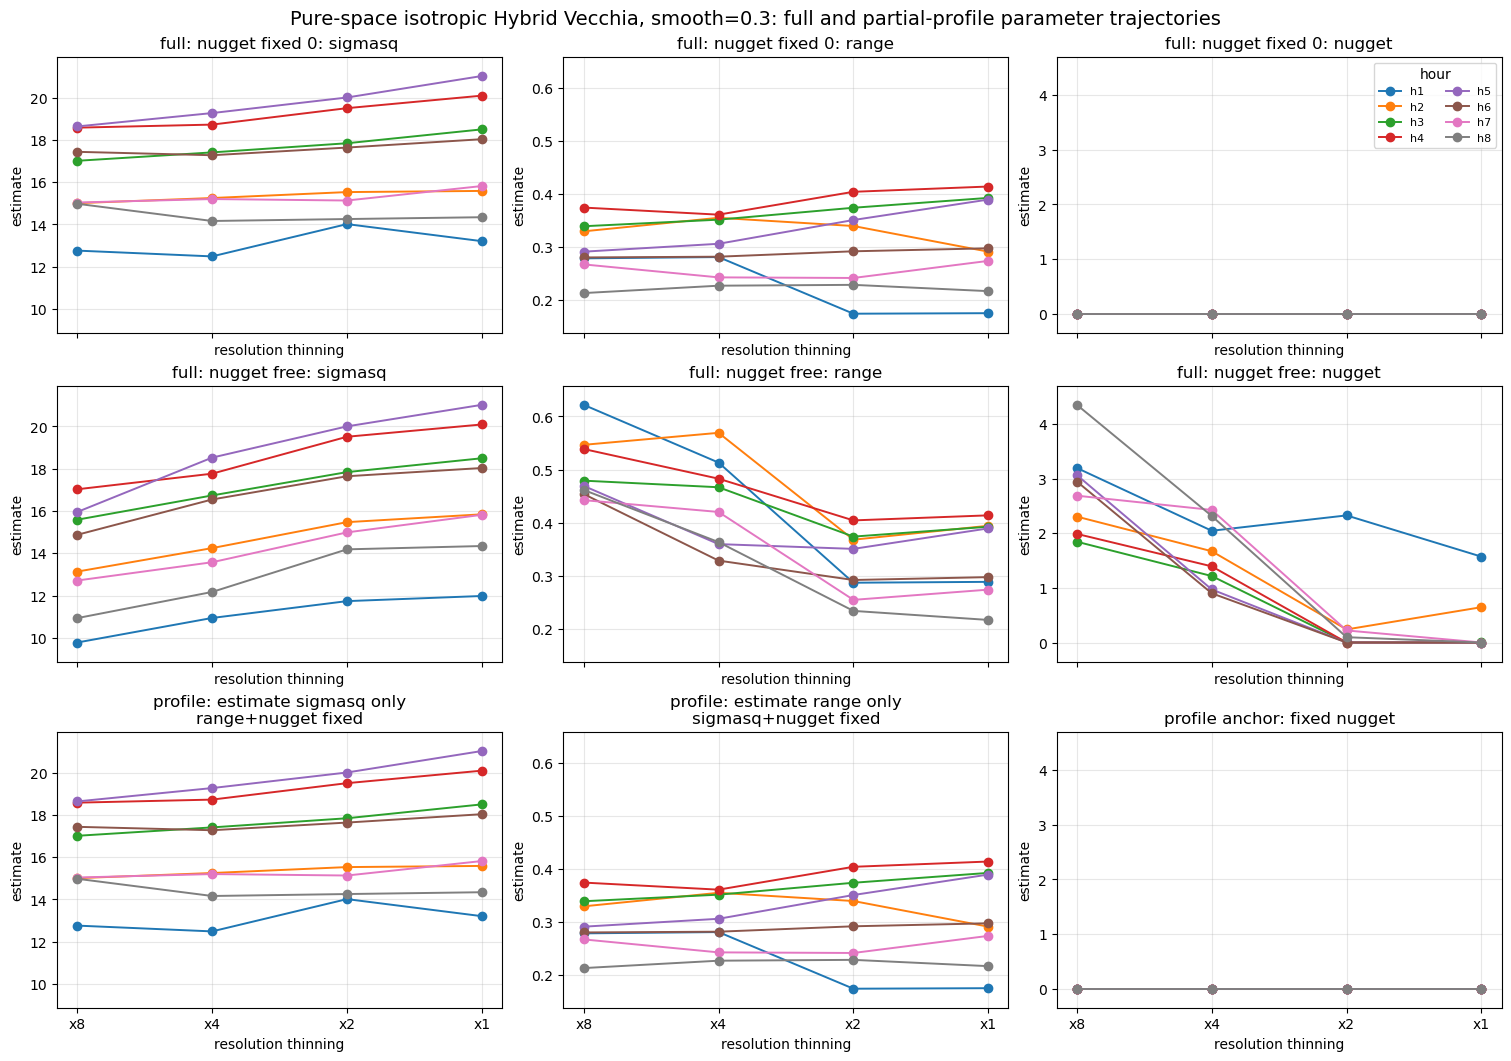

In [9]:
# %%
# Partial-profile fits anchored at the full-fit estimates.
# sigma_only: estimate sigmasq only; keep range and nugget fixed at the full-fit estimates.
# range_only: estimate range only; keep sigmasq and nugget fixed at the full-fit estimates.
RUN_PROFILE_FITS = True
PROFILE_TYPES = ['sigma_only', 'range_only']
PROFILE_LBFGS_STEPS = 8
PROFILE_GRAD_TOL = 1e-5
PROFILE_EPS = 1e-10


def safe_log_value(x, eps=PROFILE_EPS):
    return float(np.log(max(float(x), eps)))


def log_tensor_value(x, like, eps=PROFILE_EPS):
    return torch.as_tensor(np.log(max(float(x), eps)), device=like.device, dtype=like.dtype)


def profile_param_tensor(variant, profile_type, theta, anchor):
    if variant == 'nugget_free':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
            'nugget': log_tensor_value(anchor['nugget'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range'], vals['nugget']])
    if variant == 'nugget0':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range']])
    raise ValueError(f'Unknown variant: {variant}')


def profile_estimate_from_theta(profile_type, theta, anchor):
    est = dict(anchor)
    est['sigmasq' if profile_type == 'sigma_only' else 'range'] = float(torch.exp(theta.detach()).cpu().item())
    return est


def optimize_profile(model, variant, profile_type, anchor):
    free_name = 'sigmasq' if profile_type == 'sigma_only' else 'range'
    theta = torch.tensor([safe_log_value(anchor[free_name])], device=DEVICE, dtype=DTYPE, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [theta],
        lr=LBFGS_LR,
        max_iter=LBFGS_EVAL,
        max_eval=LBFGS_EVAL,
        history_size=LBFGS_HIST,
        line_search_fn='strong_wolfe',
    )

    last_loss = None
    last_iter = 0
    for i in range(PROFILE_LBFGS_STEPS):
        last_iter = i

        def closure():
            optimizer.zero_grad()
            params = profile_param_tensor(variant, profile_type, theta, anchor)
            loss = model.vecchia_batched_likelihood(params)
            loss.backward()
            return loss

        last_loss = optimizer.step(closure)
        with torch.no_grad():
            max_grad = abs(float(theta.grad.detach().item())) if theta.grad is not None else 0.0
            print(f'    {profile_type} step {i + 1}/{PROFILE_LBFGS_STEPS}: loss={float(last_loss.detach().item()):.6f}, grad={max_grad:.2e}')
            if max_grad < PROFILE_GRAD_TOL:
                break

    est = profile_estimate_from_theta(profile_type, theta, anchor)
    loss = float(last_loss.detach().cpu().item()) if isinstance(last_loss, torch.Tensor) else np.nan
    return est, loss, last_iter


def fit_partial_profiles_for_row(row):
    variant = str(row['variant'])
    hour_idx = int(row['hour_idx'])
    stride = int(row['resolution_stride'])
    anchor = {
        'sigmasq': float(row['est_sigmasq']),
        'range': float(row['est_range']),
        'nugget': float(row.get('est_nugget', 0.0)),
    }

    hour_map, time_key = load_hour_map(hour_idx)
    thin_map_regular, thin_grid_regular, _ = thin_hour_map(hour_map, stride)
    hybrid_order, thin_grid, nns_map = make_hybrid_ordering(thin_grid_regular)
    thin_map = {k: v[hybrid_order].contiguous() for k, v in thin_map_regular.items()}
    model = build_model(variant, thin_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    out_rows = []
    for profile_type in PROFILE_TYPES:
        print('\n' + '-' * 90)
        print(f"profile={profile_type} | {variant} | hour={hour_idx + 1} | {resolution_label(stride)} | anchor={anchor}")
        t_fit = time.time()
        est, loss, fit_iter = optimize_profile(model, variant, profile_type, anchor)
        fit_s = time.time() - t_fit
        profile_row = dict(row)
        profile_row.update({
            'fit_type': profile_type,
            'profile_type': profile_type,
            'fixed_sigmasq': anchor['sigmasq'] if profile_type == 'range_only' else np.nan,
            'fixed_range': anchor['range'] if profile_type == 'sigma_only' else np.nan,
            'fixed_nugget': anchor['nugget'],
            'loss': float(loss),
            'fit_iter_raw': int(fit_iter),
            'fit_steps_reported': int(fit_iter) + 1,
            'precompute_s': float(pre_s),
            'fit_s': float(fit_s),
            'total_s': float(pre_s + fit_s),
            'est_sigmasq': float(est['sigmasq']),
            'est_range': float(est['range']),
            'est_nugget': float(est.get('nugget', 0.0)),
            **diag,
        })
        out_rows.append(profile_row)

    del model, hour_map, thin_map_regular, thin_map
    empty_cache()
    return out_rows


profile_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv'
if RUN_PROFILE_FITS:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    profile_rows = []
    for _, fit_row in fit_df.iterrows():
        profile_rows.extend(fit_partial_profiles_for_row(fit_row))
        tmp = round_df(pd.DataFrame(profile_rows))
        tmp.to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')

    profile_df = pd.DataFrame(profile_rows)
    round_df(profile_df).to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
else:
    profile_df = pd.read_csv(profile_path) if profile_path.exists() else pd.DataFrame()

print('Saved partial-profile fits:', profile_path)
display(round_df(profile_df[['variant','profile_type','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','fixed_sigmasq','fixed_range','fixed_nugget','n_grid','n_valid','total_s']]))

# %%
# Combined parameter trajectories:
# row 1: nugget0 full fit
# row 2: nugget_free full fit
# row 3: nugget0 partial profiles anchored at the full-fit estimates
if 'fit_df' not in globals() or fit_df.empty:
    fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')
if 'profile_df' not in globals() or profile_df.empty:
    profile_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv')

full_plot_df = fit_df.copy()
full_plot_df['resolution_label'] = pd.Categorical(
    full_plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
full_plot_df = full_plot_df.sort_values(['variant', 'hour_idx', 'resolution_label'])

prof_plot_df = profile_df.copy()
prof_plot_df['resolution_label'] = pd.Categorical(
    prof_plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
prof_plot_df = prof_plot_df.sort_values(['variant', 'profile_type', 'hour_idx', 'resolution_label'])
prof_anchor_variant = 'nugget0'

combined_param_values = {
    'sigmasq': [full_plot_df['est_sigmasq'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'sigma_only', 'est_sigmasq']],
    'range': [full_plot_df['est_range'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'range_only', 'est_range']],
    'nugget': [full_plot_df['est_nugget'], prof_plot_df['fixed_nugget']],
}
combined_param_ylims = {}
for p, series_list in combined_param_values.items():
    vals = pd.concat([pd.to_numeric(s, errors='coerce') for s in series_list], ignore_index=True)
    vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
    if vals.empty:
        combined_param_ylims[p] = (0.0, 1.0)
        continue
    lo, hi = float(vals.min()), float(vals.max())
    pad = max(abs(hi) * 0.05, 0.05) if np.isclose(lo, hi) else 0.08 * (hi - lo)
    if p == 'nugget':
        lo = min(0.0, lo)
    combined_param_ylims[p] = (lo - pad, hi + pad)

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5), constrained_layout=True, sharex=True)
full_rows = [('nugget0', 'full: nugget fixed 0'), ('nugget_free', 'full: nugget free')]
params_to_plot = ['sigmasq', 'range', 'nugget']
for r, (variant, row_label) in enumerate(full_rows):
    sub_v = full_plot_df[full_plot_df['variant'] == variant]
    for c, p in enumerate(params_to_plot):
        ax = axes[r, c]
        for hour_idx, sub in sub_v.groupby('hour_idx'):
            ax.plot(sub['resolution_label'].astype(str), sub[f'est_{p}'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
        ax.set_title(f'{row_label}: {p}')
        ax.set_xlabel('resolution thinning')
        ax.set_ylabel('estimate')
        ax.set_ylim(*combined_param_ylims[p])
        ax.grid(True, alpha=0.3)

sigma_prof = prof_plot_df[(prof_plot_df['variant'] == prof_anchor_variant) & (prof_plot_df['profile_type'] == 'sigma_only')]
range_prof = prof_plot_df[(prof_plot_df['variant'] == prof_anchor_variant) & (prof_plot_df['profile_type'] == 'range_only')]

ax = axes[2, 0]
for hour_idx, sub in sigma_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['est_sigmasq'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile: estimate sigmasq only\nrange+nugget fixed')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['sigmasq'])
ax.grid(True, alpha=0.3)

ax = axes[2, 1]
for hour_idx, sub in range_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['est_range'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile: estimate range only\nsigmasq+nugget fixed')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['range'])
ax.grid(True, alpha=0.3)

ax = axes[2, 2]
for hour_idx, sub in sigma_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['fixed_nugget'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile anchor: fixed nugget')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['nugget'])
ax.grid(True, alpha=0.3)

axes[0, -1].legend(ncol=2, fontsize=8, title='hour')
fig.suptitle(f'Pure-space isotropic Hybrid Vecchia, smooth={SMOOTH}: full and partial-profile parameter trajectories', fontsize=14)
param_plot_path = OUT_DIR / f'{OUT_PREFIX}_parameter_trajectories.png'
fig.savefig(param_plot_path, dpi=180, bbox_inches='tight')
print('Saved combined parameter plot:', param_plot_path)
plt.show()


## Spectral diagnostic

The empirical spectrum uses the same thinned points as each fit. Residuals are computed after an OLS `intercept + lat + lon` detrend, placed back onto the full grid, tapered, zero-filled, FFTed, and radially averaged. For `nugget_free`, the theoretical spectrum includes the fitted flat nugget component before being scaled to the empirical curve.


In [10]:
SPECTRAL_SMOOTH = SMOOTH
RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = True
EPS = 1e-12

_lat_key = np.round(grid_coords_full[:, 0], 10)
_lon_key = np.round(grid_coords_full[:, 1], 10)
lat_vals = np.sort(np.unique(_lat_key))
lon_vals = np.sort(np.unique(_lon_key))
lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
local_to_row = np.asarray([lat_to_row[float(v)] for v in _lat_key], dtype=np.int64)
local_to_col = np.asarray([lon_to_col[float(v)] for v in _lon_key], dtype=np.int64)
N_LAT, N_LON = len(lat_vals), len(lon_vals)
LAT_STEP = float(np.median(np.diff(lat_vals))) if N_LAT > 1 else 1.0
LON_STEP = float(np.median(np.diff(lon_vals))) if N_LON > 1 else 1.0
print('spectral full grid:', (N_LAT, N_LON), 'lat/lon step:', LAT_STEP, LON_STEP)


def detrended_residual_grid(hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, thin_idx = thin_hour_map(hour_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)
    if valid.sum() < 4:
        raise ValueError(f'Not enough valid points for hour={hour_idx}, stride={stride}')

    X = np.column_stack([
        np.ones(valid.sum()),
        lat[valid] - np.nanmean(lat[valid]),
        lon[valid] - np.nanmean(lon[valid]),
    ])
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    X_all = np.column_stack([
        np.ones(len(y)),
        lat - np.nanmean(lat[valid]),
        lon - np.nanmean(lon[valid]),
    ])
    resid = y - X_all @ beta

    grid = np.full((N_LAT, N_LON), np.nan, dtype=float)
    mask = np.zeros((N_LAT, N_LON), dtype=float)
    keep_idx = thin_idx[valid]
    rr = local_to_row[keep_idx]
    cc = local_to_col[keep_idx]
    grid[rr, cc] = resid[valid]
    mask[rr, cc] = 1.0
    return grid, mask, time_key, int(valid.sum())


def masked_periodogram(grid, mask):
    z = np.nan_to_num(grid, nan=0.0).astype(float)
    z = z - (np.sum(z * mask) / max(float(mask.sum()), 1.0))
    win = np.outer(np.hanning(z.shape[0]), np.hanning(z.shape[1])) if APPLY_HANN else np.ones_like(z)
    zw = z * win
    norm = np.sum((mask * win) ** 2)
    norm = norm if norm > EPS else 1.0
    return np.abs(np.fft.fftshift(np.fft.fft2(zw))) ** 2 / norm


def frequency_grid():
    fy = np.fft.fftshift(np.fft.fftfreq(N_LAT, d=LAT_STEP))
    fx = np.fft.fftshift(np.fft.fftfreq(N_LON, d=LON_STEP))
    omega_y = 2.0 * np.pi * fy
    omega_x = 2.0 * np.pi * fx
    OX, OY = np.meshgrid(omega_x, omega_y)
    k = np.sqrt(OX ** 2 + OY ** 2)
    return k, OX ** 2 + OY ** 2

K_RADIAL, OMEGA2 = frequency_grid()
_positive_k = K_RADIAL[np.isfinite(K_RADIAL) & (K_RADIAL > 0)]
K_MAX = float(np.quantile(_positive_k, RADIAL_QMAX))
RADIAL_BINS = np.linspace(0.0, K_MAX, RADIAL_N_BINS + 1)


def matern_spectrum_shape(sigmasq, range_, nugget, smooth):
    nu = float(smooth)
    alpha = 2.0 * nu / max(float(range_) ** 2, EPS)
    matern = float(sigmasq) * (alpha + OMEGA2) ** (-(nu + 1.0))
    return matern + max(float(nugget), 0.0)


def radial_average(surface):
    vals = np.asarray(surface, dtype=float).ravel()
    kk = K_RADIAL.ravel()
    good = np.isfinite(vals) & np.isfinite(kk) & (kk > 0) & (kk <= K_MAX)
    bin_idx = np.digitize(kk[good], RADIAL_BINS) - 1
    rows = []
    vg = vals[good]
    for b in range(RADIAL_N_BINS):
        m = bin_idx == b
        if not np.any(m):
            continue
        rows.append({
            'k_bin': b,
            'k_mid': 0.5 * (RADIAL_BINS[b] + RADIAL_BINS[b + 1]),
            'spectrum': float(np.nanmean(vg[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


spectral full grid: (114, 159) lat/lon step: 0.04400000000000004 0.06300000000000239


In [11]:
if RUN_SPECTRUM:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    spectral_rows = []
    for r in fit_df.itertuples(index=False):
        grid, mask, time_key, n_valid_spectrum = detrended_residual_grid(int(r.hour_idx), int(r.resolution_stride))
        data_p = masked_periodogram(grid, mask)
        theory_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH)

        data_rad = radial_average(data_p).rename(columns={'spectrum': 'data_spectrum'})
        theory_rad = radial_average(theory_p).rename(columns={'spectrum': 'theory_spectrum'})
        merged = data_rad.merge(theory_rad[['k_bin', 'theory_spectrum']], on='k_bin', how='inner')

        d = merged['data_spectrum'].to_numpy(dtype=float)
        t = merged['theory_spectrum'].to_numpy(dtype=float)
        good = np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
        scale = float(np.nanmedian(d[good] / t[good])) if good.any() else 1.0
        merged['theory_spectrum_scaled'] = merged['theory_spectrum'] * scale

        for m in merged.itertuples(index=False):
            spectral_rows.append({
                'date_str': r.date_str,
                'hour_idx': int(r.hour_idx),
                'time_key': time_key,
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': r.resolution_label,
                'variant': r.variant,
                'smooth': float(r.smooth),
                'n_valid_spectrum': n_valid_spectrum,
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'n_freq': int(m.n_freq),
                'data_spectrum': float(m.data_spectrum),
                'theory_spectrum_raw': float(m.theory_spectrum),
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

    spectral_df = pd.DataFrame(spectral_rows)
    spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
    spectral_df.to_csv(spectral_path, index=False)
    print('Saved radial spectrum:', spectral_path)
    display(round_df(spectral_df.head(12)))


Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_radial_spectrum.csv


,date_str,hour_idx,time_key,resolution_stride,resolution_label,variant,smooth,n_valid_spectrum,est_sigmasq,est_range,est_nugget,k_bin,k_mid,n_freq,data_spectrum,theory_spectrum_raw,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,0,0.5729,2,0.5687,7.3115,15.1956,2.0783
1,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,1,1.7187,18,525.2061,4.7188,9.8072,2.0783
2,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,2,2.8645,26,122.2696,3.7069,7.7042,2.0783
3,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,3,4.0103,42,48.2301,3.4214,7.1108,2.0783
4,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,4,5.1561,42,19.2596,3.3170,6.8938,2.0783
5,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,5,6.3019,60,14.9271,3.2709,6.7979,2.0783
6,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,6,7.4477,66,12.0839,3.2441,6.7423,2.0783
7,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,7,8.5935,86,10.7305,3.2285,6.7099,2.0783
8,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,8,9.7393,86,10.0378,3.2186,6.6894,2.0783
9,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.3,2259,9.7804,0.6218,3.1934,9,10.8851,98,7.5220,3.2126,6.6768,2.0783


In [12]:
# %%
# Resolution-aware spectrum summaries.
# Data spectrum is retained only below each thinning's effective Nyquist.
# Fitted theoretical spectrum is retained on the full-grid frequency axis.
if 'spectral_df' not in globals():
    spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv')

plot_spec = spectral_df.copy()
plot_spec['resolution_label'] = pd.Categorical(
    plot_spec['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

FULL_K_PLOT_MAX = float(plot_spec['k_mid'].max())
plot_spec['effective_k_max'] = FULL_K_PLOT_MAX / plot_spec['resolution_stride'].astype(float)
plot_spec_low = plot_spec[plot_spec['k_mid'] <= plot_spec['effective_k_max']].copy()

avg_low_data = (
    plot_spec_low
    .groupby(['variant', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        effective_k_max=('effective_k_max', 'mean'),
    )
    .reset_index()
)
low_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum_lowfreq_only_avg.csv'
avg_low_data.to_csv(low_path, index=False)
print('Saved low-frequency data spectrum:', low_path)

avg_theory_full = (
    plot_spec
    .groupby(['variant', 'resolution_label', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)


Saved low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_radial_spectrum_lowfreq_only_avg.csv


Saved partial-profile radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_partial_profile_radial_spectrum.csv
Saved partial-profile low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_partial_profile_radial_spectrum_lowfreq_only_avg.csv
Fixed combined spectrum y-limits: (0.1, 100000.0)
Saved combined spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_s03_nugget_compare_hybrid_050826_data_lowfreq_theory_full_by_variant_resolution.png


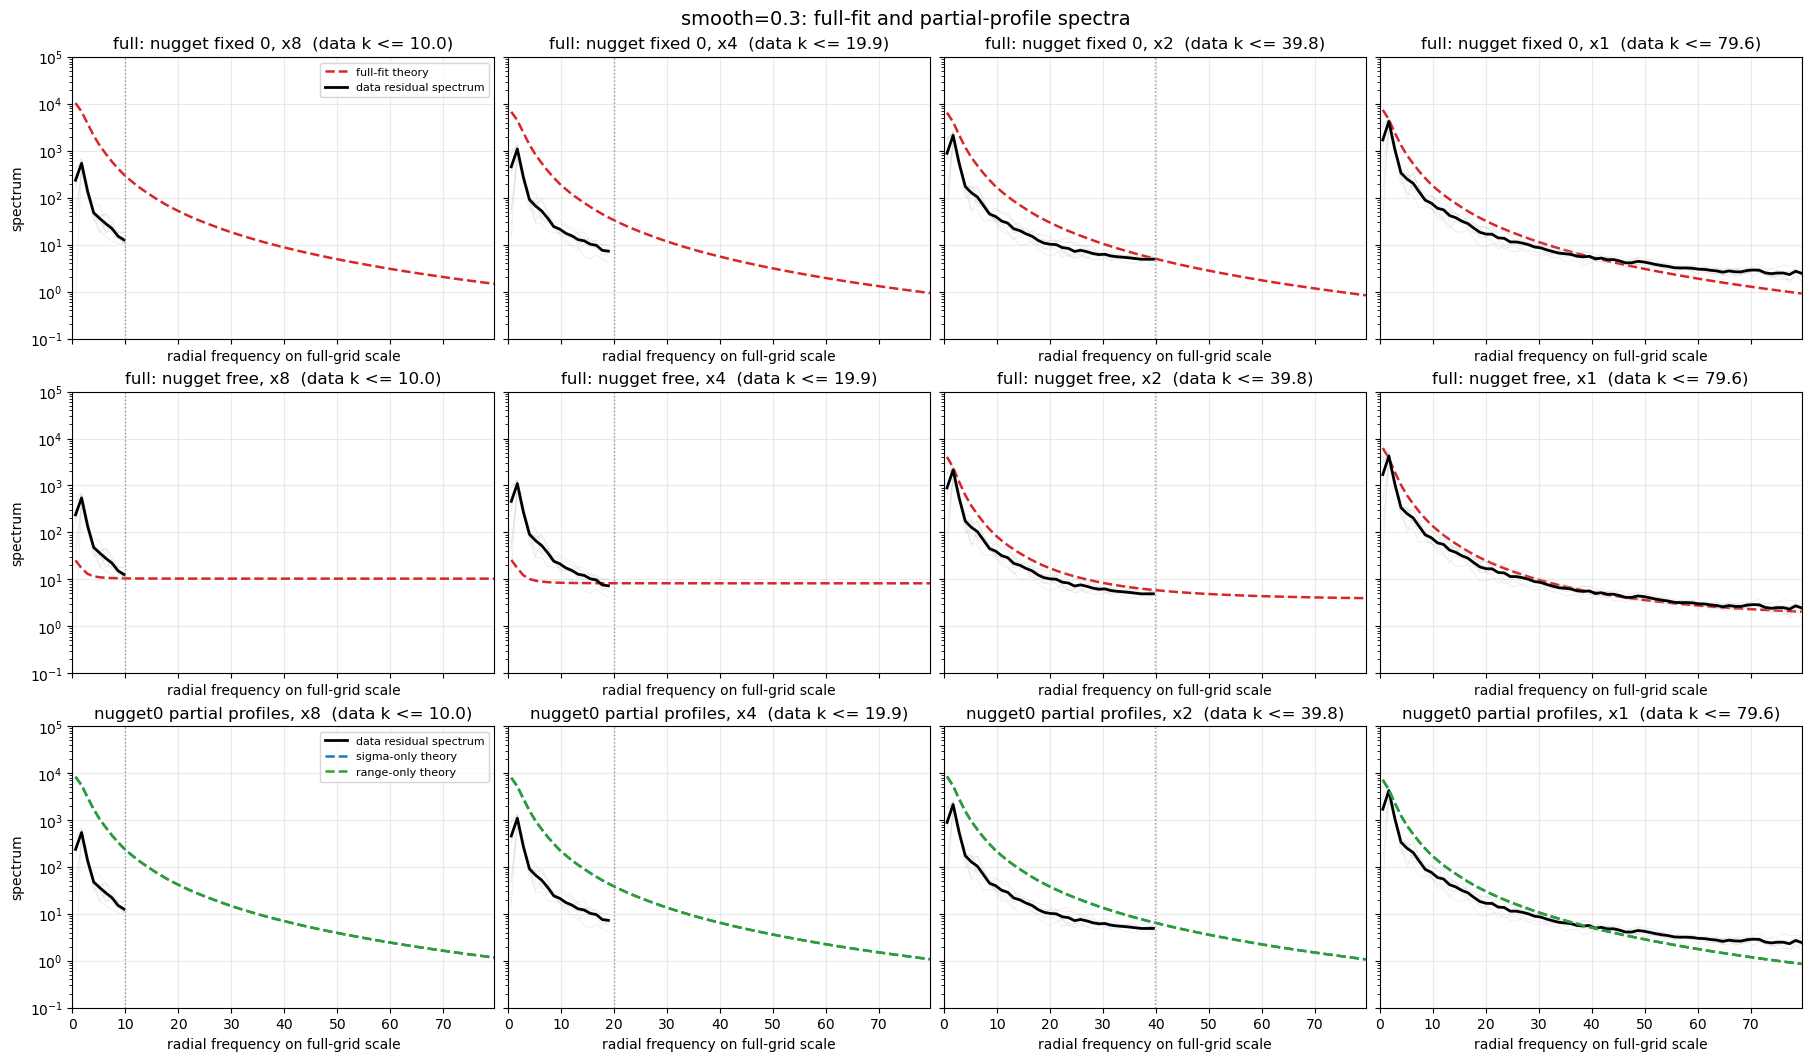

In [13]:
# %%
# Spectral diagnostics for partial-profile fits.
if 'profile_df' not in globals() or profile_df.empty:
    profile_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv')

if RUN_SPECTRUM and not profile_df.empty:
    profile_spectral_rows = []
    for r in profile_df.itertuples(index=False):
        grid, mask, time_key, n_valid_spectrum = detrended_residual_grid(int(r.hour_idx), int(r.resolution_stride))
        data_p = masked_periodogram(grid, mask)
        theory_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH)

        data_rad = radial_average(data_p).rename(columns={'spectrum': 'data_spectrum'})
        theory_rad = radial_average(theory_p).rename(columns={'spectrum': 'theory_spectrum'})
        merged = data_rad.merge(theory_rad[['k_bin', 'theory_spectrum']], on='k_bin', how='inner')

        d = merged['data_spectrum'].to_numpy(dtype=float)
        t = merged['theory_spectrum'].to_numpy(dtype=float)
        good = np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
        scale = float(np.exp(np.mean(np.log(d[good]) - np.log(t[good])))) if good.any() else 1.0
        merged['theory_spectrum_scaled'] = merged['theory_spectrum'] * scale

        for m in merged.itertuples(index=False):
            profile_spectral_rows.append({
                'date_str': str(r.date_str),
                'hour_idx': int(r.hour_idx),
                'time_key': str(r.time_key),
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': str(r.resolution_label),
                'variant': str(r.variant),
                'profile_type': str(r.profile_type),
                'smooth': float(SMOOTH),
                'n_valid_spectrum': int(n_valid_spectrum),
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'n_freq': int(m.n_freq),
                'data_spectrum': float(m.data_spectrum),
                'theory_spectrum_raw': float(m.theory_spectrum),
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

    profile_spectral_df = pd.DataFrame(profile_spectral_rows)
    profile_spectral_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_radial_spectrum.csv'
    profile_spectral_df.to_csv(profile_spectral_path, index=False)
    print('Saved partial-profile radial spectrum:', profile_spectral_path)

    plot_prof = profile_spectral_df.copy()
    plot_prof['resolution_label'] = pd.Categorical(
        plot_prof['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
    )
    if 'FULL_K_PLOT_MAX' not in globals():
        FULL_K_PLOT_MAX = float(plot_prof['k_mid'].max())
    plot_prof['effective_k_max'] = FULL_K_PLOT_MAX / plot_prof['resolution_stride'].astype(float)
    plot_prof_low = plot_prof[plot_prof['k_mid'] <= plot_prof['effective_k_max']].copy()

    avg_prof_low = (
        plot_prof_low
        .groupby(['variant', 'profile_type', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
        .agg(
            k_mid=('k_mid', 'mean'),
            data_spectrum=('data_spectrum', 'mean'),
            n_hours=('hour_idx', 'nunique'),
            effective_k_max=('effective_k_max', 'mean'),
        )
        .reset_index()
    )
    avg_prof_theory = (
        plot_prof
        .groupby(['variant', 'profile_type', 'resolution_label', 'k_bin'], observed=False)
        .agg(
            k_mid=('k_mid', 'mean'),
            theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
        )
        .reset_index()
    )
    avg_prof_low_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_radial_spectrum_lowfreq_only_avg.csv'
    avg_prof_low.to_csv(avg_prof_low_path, index=False)
    print('Saved partial-profile low-frequency data spectrum:', avg_prof_low_path)

    positive_spectrum_vals = pd.concat(
        [
            pd.to_numeric(avg_low_data['data_spectrum'], errors='coerce'),
            pd.to_numeric(avg_theory_full['theory_spectrum_scaled'], errors='coerce'),
            pd.to_numeric(avg_prof_low['data_spectrum'], errors='coerce'),
            pd.to_numeric(avg_prof_theory['theory_spectrum_scaled'], errors='coerce'),
        ],
        ignore_index=True,
    ).replace([np.inf, -np.inf], np.nan).dropna()
    positive_spectrum_vals = positive_spectrum_vals[positive_spectrum_vals > 0]
    if positive_spectrum_vals.empty:
        SPECTRUM_YLIM = (1e-1, 1e4)
    else:
        SPECTRUM_YLIM = (
            10 ** np.floor(np.log10(float(positive_spectrum_vals.min()))),
            10 ** np.ceil(np.log10(float(positive_spectrum_vals.max()))),
        )
    print('Fixed combined spectrum y-limits:', SPECTRUM_YLIM)

    labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
    row_specs = [
        ('nugget0', 'full: nugget fixed 0'),
        ('nugget_free', 'full: nugget free'),
        ('profiles', 'nugget0 partial profiles'),
    ]
    fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(18, 10.5), constrained_layout=True, sharex=True, sharey=True)
    for i, (row_key, row_title) in enumerate(row_specs):
        for j, label in enumerate(labels_order):
            ax = axes[i, j]
            if row_key == 'profiles':
                sub_data = avg_prof_low[
                    (avg_prof_low['variant'] == 'nugget0')
                    & (avg_prof_low['profile_type'] == 'sigma_only')
                    & (avg_prof_low['resolution_label'].astype(str) == label)
                    & (avg_prof_low['k_mid'] > 0)
                ].copy()
                sub_sigma = avg_prof_theory[
                    (avg_prof_theory['variant'] == 'nugget0')
                    & (avg_prof_theory['profile_type'] == 'sigma_only')
                    & (avg_prof_theory['resolution_label'].astype(str) == label)
                    & (avg_prof_theory['k_mid'] > 0)
                ].copy()
                sub_range = avg_prof_theory[
                    (avg_prof_theory['variant'] == 'nugget0')
                    & (avg_prof_theory['profile_type'] == 'range_only')
                    & (avg_prof_theory['resolution_label'].astype(str) == label)
                    & (avg_prof_theory['k_mid'] > 0)
                ].copy()
                hour_sub = plot_prof_low[
                    (plot_prof_low['variant'] == 'nugget0')
                    & (plot_prof_low['profile_type'] == 'sigma_only')
                    & (plot_prof_low['resolution_label'].astype(str) == label)
                    & (plot_prof_low['k_mid'] > 0)
                ]
                if sub_data.empty or sub_sigma.empty or sub_range.empty:
                    ax.set_visible(False)
                    continue
                k_cut = float(sub_data['effective_k_max'].iloc[0])
                for _, hs in hour_sub.groupby('hour_idx'):
                    ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.7', alpha=0.20, linewidth=0.7)
                ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.0, label='data residual spectrum')
                ax.plot(sub_sigma['k_mid'], sub_sigma['theory_spectrum_scaled'], color='tab:blue', linewidth=1.8, linestyle='--', label='sigma-only theory')
                ax.plot(sub_range['k_mid'], sub_range['theory_spectrum_scaled'], color='tab:green', linewidth=1.8, linestyle='--', label='range-only theory')
            else:
                sub_data = avg_low_data[
                    (avg_low_data['variant'] == row_key)
                    & (avg_low_data['resolution_label'].astype(str) == label)
                    & (avg_low_data['k_mid'] > 0)
                ].copy()
                sub_theory = avg_theory_full[
                    (avg_theory_full['variant'] == row_key)
                    & (avg_theory_full['resolution_label'].astype(str) == label)
                    & (avg_theory_full['k_mid'] > 0)
                ].copy()
                hour_sub = plot_spec_low[
                    (plot_spec_low['variant'] == row_key)
                    & (plot_spec_low['resolution_label'].astype(str) == label)
                    & (plot_spec_low['k_mid'] > 0)
                ]
                if sub_data.empty or sub_theory.empty:
                    ax.set_visible(False)
                    continue
                k_cut = float(sub_data['effective_k_max'].iloc[0])
                ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=1.8, linestyle='--', label='full-fit theory')
                for _, hs in hour_sub.groupby('hour_idx'):
                    ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.7', alpha=0.22, linewidth=0.7)
                ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.0, label='data residual spectrum')

            ax.axvline(k_cut, color='0.55', linewidth=1.0, linestyle=':', alpha=0.9)
            ax.set_xlim(0, FULL_K_PLOT_MAX)
            ax.set_ylim(*SPECTRUM_YLIM)
            ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
            ax.set_xlabel('radial frequency on full-grid scale')
            if j == 0:
                ax.set_ylabel('spectrum')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.25)
    axes[0, 0].legend(fontsize=8)
    axes[2, 0].legend(fontsize=8)
    fig.suptitle(f'smooth={SMOOTH}: full-fit and partial-profile spectra', fontsize=14)
    combined_spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_data_lowfreq_theory_full_by_variant_resolution.png'
    fig.savefig(combined_spectrum_plot_path, dpi=180, bbox_inches='tight')
    print('Saved combined spectrum plot:', combined_spectrum_plot_path)
    plt.show()
